# Decision Trees

A Decision Tree is a supervised learning algorithm used for both classification and regression tasks. It builds a model in the form of a tree structure, where each internal node represents a "test" on an attribute (e.g., whether a feature value is greater than a threshold), each branch represents the outcome of the test, and each leaf node represents a class label (in classification) or a predicted value (in regression). The path from the root to a leaf node represents a set of decision rules.


The core idea behind a decision tree is to partition the data into subsets based on the most significant features until the subsets become homogeneous enough with respect to the target variable, or until a stopping criterion is met. This recursive partitioning creates a tree-like flow chart that helps in making decisions.

**Key advantages of Decision Trees include**:

* **Interpretability and Simplicity**: Easy to understand and visualize.

* **Little or no data preparation**: Decision trees are not sensitive to the scale of features, and they do not assume any form of distribution.

* **Handles both numerical and categorical features**: Decision Trees can naturally handle different types of features.

* **Robust to outliers**: Outliers in the training data don't significantly affect the split logic, as the split is based on the relative order of feature values, not their absolute values.

* **Feature Selection is Implicit**: Features that are more important for splitting the data are prioritized at the top of the tree.

However, they can also be prone to:

* **Overfitting**: Especially with deep trees, they can memorize the training data and perform poorly on unseen data.

* **Instability**: Small variations in the data can lead to a completely different tree structure.


### How the Algorithms Work:

The fundamental process of building a decision tree is similar for both regression and classification, but the specific criteria used for splitting and the final prediction method differ.

1.  **Splitting:** The algorithm starts with the entire dataset at the root node. It then searches for the best split point (a feature and a threshold value for numerical features, or categories for categorical features) that minimizes the impurity (or maximizes homogeneity) of the resulting subsets.

    * **For Regression:** Common impurity measures (also known as splitting criteria or cost functions) aim to minimize the variance or error within each subset. These include:
        * **Mean Squared Error (MSE):** Aims to minimize the sum of squared differences between the actual and predicted values within each node.
        * **Mean Absolute Error (MAE):** Aims to minimize the sum of absolute differences between the actual and predicted values within each node.

    * **For Classification:** Common impurity measures aim to maximize the homogeneity of class labels within each subset. These include:
        * **Gini Impurity:** Measures how often a randomly chosen element from the set would be incorrectly labeled if it were randomly labeled according to the distribution of labels in the subset. A lower Gini impurity indicates higher purity (more instances of a single class). It is calculated as the sum of the square of the probability of each class $p_i$ subtracted from one. $$Gini(D) = 1 - \sum_{i=1}^{C}(p_i)^2$$ Where $D$ is the node (dataset), $C$ is the number of classes, and $p_i$ is the fraction of samples belonging to class $i$ in $D$.

        * **Entropy:** A measure of disorder or uncertainty. The goal is to maximize "Information Gain," which is the reduction in entropy after a dataset is split on an attribute. A lower entropy indicates higher purity. The goal is to create subsets where most (ideally all) instances belong to the same class. Entropy is calculated as: $$ Entropy(D) = -\sum_{i=1}^{C}log_2(p_i) $$ Where $D$, $C$, and $p_i$ are defined as above. 

2.  **Recursive Partitioning:** This splitting process is applied recursively to each new subset, creating branches and nodes. The algorithm continues to find the best split within each newly formed node until a stopping criterion is met. Common stopping criteria include:

    * **Maximum Depth of the Tree:** A predefined limit on how deep the tree can grow.
    * **Minimum Number of Samples per Leaf:** A threshold for the minimum number of data points required to be in a leaf node. If a split would result in a leaf with fewer samples, the split is not made.
    * **Minimum Impurity Decrease:** A threshold for the minimum reduction in impurity required for a split to be considered valid. If a split does not significantly reduce impurity, it is not made.
    * **All Instances in a Node Belong to the Same Class (for Classification) or have the Same Value (for Regression):** If a node becomes perfectly pure, there's no need to split further.

3.  **Prediction:** Once the tree is built and trained, to predict a value for a new, unseen data point:

    * **For Regression:** The new data point traverses the tree from the root to a specific leaf node based on its feature values. The predicted value at the leaf node is typically the **average (mean)** of the target values of all training samples that fell into that particular leaf. Some implementations might use the median.

    * **For Classification:** The new data point traverses the tree from the root to a specific leaf node. The predicted class label for the new data point is the **majority class** among all training samples that fell into that leaf. The probability of belonging to each class can also be estimated based on the proportion of each class within that leaf.

In this notebook, we will use numpy to generate some sample data and Scikit-Learn to build decision tree models. Scikit-Learn uses the Classification and Regression Tree (CART) algorithm to train Decision Trees.

## Decision Tree Regression

Decision Tree Regression is a technique that uses a decision tree to predict a continuous target variable. Instead of predicting a class label at the leaf nodes, it predicts a numerical value.

In [3]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

In [4]:
# Generate sample data
np.random.seed(42) # for reproducibility
X = np.sort(5 * np.random.rand(100, 1), axis=0) # 100 samples, 1 feature
y = np.sin(X).ravel() + np.random.randn(100) * 0.1 # Non-linear relationship with some noise

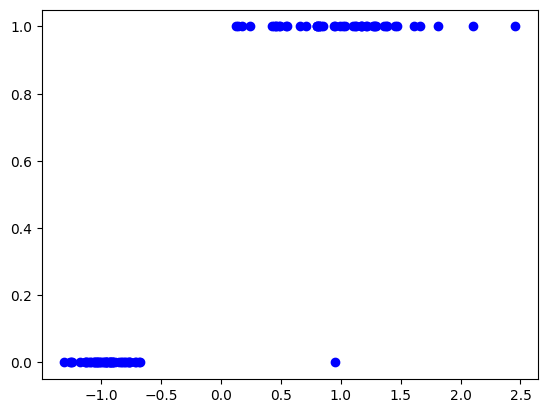

In [20]:
plt.scatter(X, y, color='blue', label='Data points')

In [19]:
# Create a Decision Tree Regressor object
# max_depth controls the maximum depth of the tree. A smaller value prevents overfitting.
regressor = DecisionTreeRegressor(max_depth=2, random_state=42)

# Train the model
regressor.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


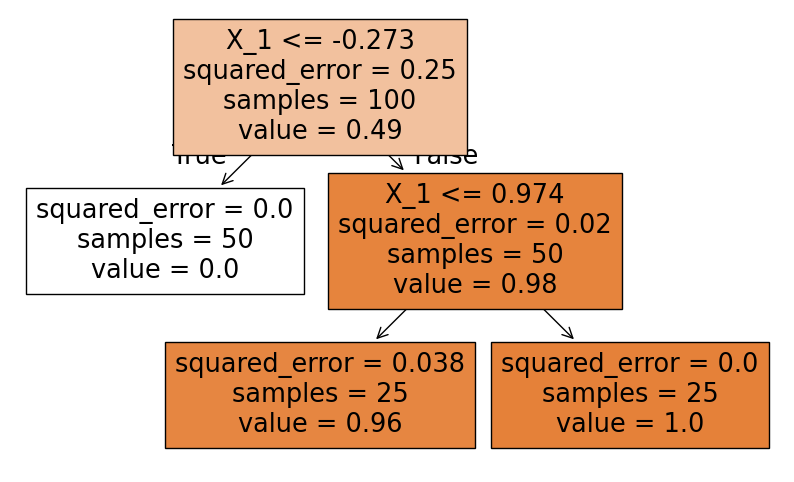

In [14]:
plt.figure(figsize=(10, 6))
plot_tree(regressor, filled=True, feature_names=["X_1"]);

### Intrepreting the tree plot

Suppose we want to make a prediction based on the value of the feature or variable "X_1" with the tree. It starts at the root node (at the top). The root node asks wether the value of "X_1" is less than or equal to a particular threshold, if it is then we move down to the root's left child node. Then we ask a similar question, is "X_1" at this node less or equal to a threshold. If it is, we move down to node's left child node or right child node if it is not. In this case, it is a leaf node, so we don't ask any questions here. We simply look at the predicted value at this node.

Each node’s samples attribute counts how many training instances it applies to. For example, at the root node, there are 100 training instances where the value of X_1 is less than or equal to 3.088, and 34 training instances where the value of X_1 is greater than 3.088 but less than or equal to 3.968.

A node's value attribute is average prediction of the target at that node. At the node where X_1 is less than or equal to 3.968, prediction at that node is the average value of the target variable for 34 training instances at the node. If the condition is true, then the prediction at the leaf node the average value of the target variable for the 16 training instances at the node.

The squared error is the Mean Squared Error of the samples at that node. The goal of the algorithm is to minimize this value at the leaf nodes.

In the tree plot:

**squared_error**: This indicates the Mean Squared Error of the samples at that node. The goal of the algorithm is to minimize this value at the leaf nodes.

**samples**: The number of training samples that reach this node.

**value**: For a regression tree, this is the predicted value at that node. In an internal node, it's the average of the target values of all samples that passed through that node. In a leaf node, this is the final predicted output for any new data point that lands in this leaf.

**X_1 <= [threshold]**: This is the splitting rule. X[0] refers to the first (and in our case, only) feature. The tree splits the data based on whether this feature's value is less than or equal to the specified threshold.

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import make_classification

In [16]:
# Generate sample classification data

X, y = make_classification(
    n_samples=100,
    n_features=1,
    n_informative=1,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42,
)

In [17]:
# Create a Decision Tree Classifier object
# max_depth controls the maximum depth of the tree. A smaller value prevents overfitting.
classifier = DecisionTreeClassifier(max_depth=2, random_state=42)

# Train the model
classifier.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


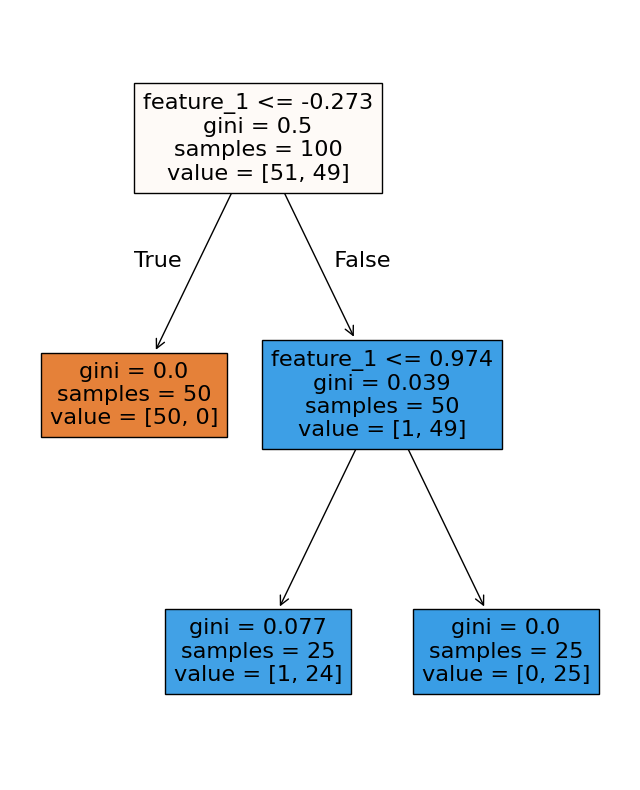

In [11]:
plt.figure(figsize=(8, 10))
plot_tree(classifier, feature_names=["feature_1"], filled=True);

### Interpreting the tree plot

The intrepretation for a classification tree is quite similar to that of a regression tree. The major difference here is that the tree splits the data in a way that minimizes the gini impurity instead of the MSE. If all samples at a node belong to a single class, Gini impurity is 0 (perfectly pure). The values also represent the number of training instances for each class in that node.

### Feature Importance

Feature importance in decision trees is a score that quantifies how much each input feature contributes to the model's predictive power or decision-making process. Essentially, it helps determine which features are the most significant when the decision tree makes its splits and final predictions. It can be accessed via the `feature_importances_` attribute of `sklearn`'s tree objects.

In [12]:
classifier.feature_importances_

array([1.])

## Tree Ensembles

A group of predictors is called an ensemble; thus, this technique is called Ensemble Learning, and an Ensemble Learning algorithm is called an Ensemble method. While individual decision trees are simple and interpretable, they often suffer from high variance (they are sensitive to small changes in the training data) and can easily overfit. Tree ensemble methods address these limitations by combining multiple decision trees to produce a more robust and accurate model. The core idea is that the "wisdom of the crowd" (multiple trees) is better than the wisdom of a single person. Therefore, if you aggregate the predictions of a group of predictors (such as classifiers or regressors), you will often get better predictions than with the best individual predictor. 

There are two primary categories of tree ensemble methods:

1. **Bagging (Bootstrap Aggregating) and Pasting**: This methods involve training multiple independent decision trees on different random subsets of the training data. It is called bagging (boot strapping) when the random subsets are sampled with replacement and called pasting when sampled without replacement. Once all predictors are trained, the ensemble can make a prediction for a new instance by simply aggregating the predictions of all predictors. The aggregation function is typically the *mode* (i.e., the most frequent prediction) for classification, or the average for regression.

2. **Boosting**: Boosting methods train trees sequentially, where each new tree attempts to correct the errors made by the previous trees in the ensemble. The core principle is to iteratively improve the model by focusing on the data points that were challenging for the earlier models. There are several boosting methods but the most popular ones are Ada-Boost (Adaptive boosting) and Gradient boosting.

    * **AdaBoost (Adaptive Boosting)**: After each round of training,  each subsequent tree focuses on the data points that were misclassified (for classification) or poorly predicted (for regression) by the preceding trees. This is often achieved by assigning higher weights to samples that are difficult to predict. Each tree is assigned a weight based on its accuracy. The final prediction is made by a weighted vote (for classification) or weighted sum (for regression) of all the learners' outputs.  The algorithm is "adaptive" because it adapts to the errors of previous models, continually refining the ensemble to reduce overall error.

    * **Gradient Boosting**: Gradient Boosting takes a slightly different, more generalized approach. Instead of reweighting data points, it trains each new tree to predict the "residuals" or "errors" of the previous ensemble of trees. The predictions from each sequential tree are then added together, with each tree's contribution scaled by a learning_rate.

    Boosting methods generally aim to reduce bias and can achieve very high accuracy, often outperforming bagging methods if tuned correctly. However, due to their sequential nature, they can be more prone to overfitting than bagging if not carefully regularized (e.g., by controlling learning_rate and max_depth or using early stopping).

In Scikit-learn, these ensemble methods are readily available within the `sklearn.ensemble` module. Specifically, `RandomForestClassifier` and `RandomForestRegressor` implement the Bagging/Pasting algorithm for classification and regression, respectively. For boosting, `AdaBoostClassifier` and `AdaBoostRegressor` implement Adaptive Boosting, while `GradientBoostingClassifier` and `GradientBoostingRegressor` implement Gradient Boosting.